In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rand = np.random.RandomState(42)
x = rand.randint(100, size=10)
print(x)

[51 92 14 71 60 20 82 86 74 74]


In [4]:
print([[x[3], x[5], x[7]]])

[[np.int32(71), np.int32(20), np.int32(86)]]


In [5]:
ind=[3,4,7]
print(x[ind])

[71 60 86]


In [6]:
ind = [[3,7], [4,5]]
print(x[ind])

[[71 86]
 [60 20]]


In [7]:
X = np.arange(12).reshape((3,4))
X 

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [8]:
row = np.array([0,1,2])
col = np.array([2,1,3])

X[row, col]

array([ 2,  5, 11])

In [9]:
row[:, np.newaxis] * col

array([[0, 0, 0],
       [2, 1, 3],
       [4, 2, 6]])

In [10]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [11]:
X[2, [2,0,1]]

array([10,  8,  9])

In [12]:
X[1:, [2,0,1]]

array([[ 6,  4,  5],
       [10,  8,  9]])

In [13]:
mask = np.array([1,0,1,0], dtype=bool)
X[row[:, np.newaxis], mask]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

In [14]:
mean = [0,0]
col = [[1,2], [2,5]]

X = rand.multivariate_normal(mean, col, 100)
X.shape


(100, 2)

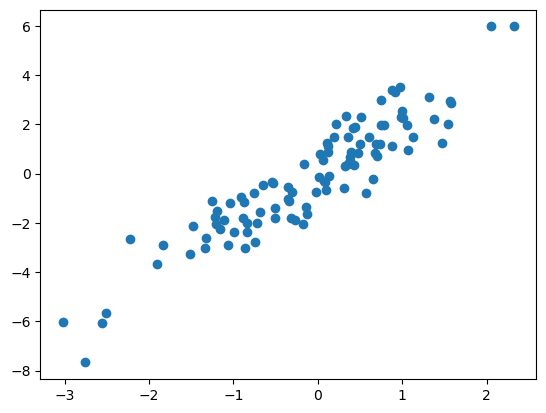

In [15]:
plt.scatter(X[:,0], X[:,1])

In [16]:
indices = np.random.choice(X.shape[0], 20, replace=False)
indices

array([40, 78, 14, 55, 19, 76, 43, 92, 15, 10, 27, 31, 64, 52, 72, 54, 24,
       33, 62, 85], dtype=int32)

In [17]:
selection = X[indices]
selection.shape

(20, 2)

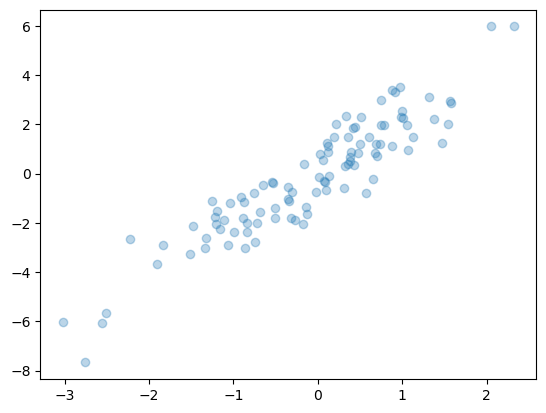

In [18]:
plt.scatter(X[:,0], X[:,1], alpha=0.3)
plt.scatter(selection[:,0], selection[:,1], facecolor='none', s=200)

In [19]:
x = np.arange(10)
i = np.array([2,1,8,4])
x[i] = 99
print(x)

[ 0 99 99  3 99  5  6  7 99  9]


In [20]:
x = np.zeros(10)
x[[0,0]] = [4,6]
print(x)

[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [21]:
i = [2,3,3,4,4,4,4]
x[i] += 1
i

[2, 3, 3, 4, 4, 4, 4]

In [22]:
x = np.zeros(10)
np.add.at(x, i, 1)
print(x)

[0. 0. 1. 2. 4. 0. 0. 0. 0. 0.]


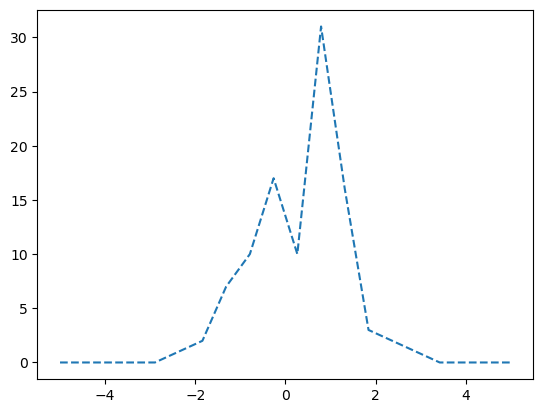

In [23]:
np.random.RandomState(42)
x = np.random.randn(100)

bins = np.linspace(-5,5,20)
counts = np.zeros_like(bins)

i = np.searchsorted(bins, x)

np.add.at(counts, i, 1)

plt.plot(bins, counts, ls='dashed')

(array([ 0.,  0.,  0.,  0.,  1.,  2.,  7., 10., 17., 10., 31., 16.,  3.,
         2.,  1.,  0.,  0.,  0.,  0.]),
 array([-5.        , -4.47368421, -3.94736842, -3.42105263, -2.89473684,
        -2.36842105, -1.84210526, -1.31578947, -0.78947368, -0.26315789,
         0.26315789,  0.78947368,  1.31578947,  1.84210526,  2.36842105,
         2.89473684,  3.42105263,  3.94736842,  4.47368421,  5.        ]),
 [<matplotlib.patches.Polygon at 0x25adfdefb60>])

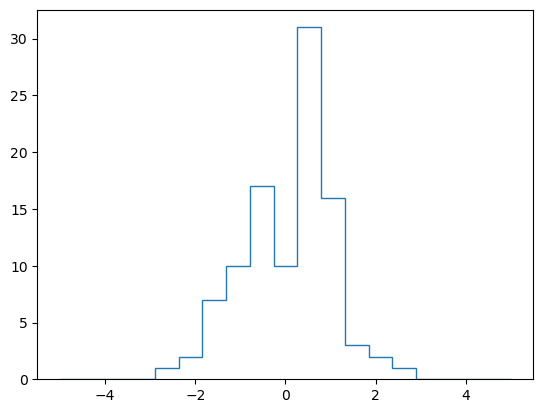

In [24]:
plt.hist(x, bins=bins, histtype='step')

In [25]:
print("Numpy routine:")
%timeit counts, edges = np.histogram(x, bins)

Numpy routine:
36.1 μs ± 1.59 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [26]:
print("Custom routine:")
%timeit np.add.at(counts, np.searchsorted(bins, x), 1)

Custom routine:
18.9 μs ± 529 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
